# BO run explorer

Pulls one Bayesian optimisation run from MLflow by experiment name and run name,
loads its artifacts, and builds views beyond what the MLflow UI shows.

The loading layer and every plot are standalone functions, so they lift into the
dashboard framework unchanged. Set `EXPERIMENT_NAME` and `RUN_NAME` below.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
from mlflow.tracking import MlflowClient


EXPERIMENT_NAME = "bo-ld50"
RUN_NAME = None   # set to a run name string, or leave None for the latest run

MU_COL = "obj:max(mu(LD50))"
SIGMA_COL = "obj:max(sigma(LD50))"


/Users/elenipsaromatis/Documents/mol-vae/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Pull the run

`get_run` resolves a run by experiment name plus optional run name. This is the
entry point the dashboard calls. With `RUN_NAME=None` it takes the most recent
run in the experiment.


In [ ]:
def get_run(experiment_name, run_name=None):
    """Return one MLflow Run, resolved by experiment name and optional run name."""

    client = MlflowClient()

    experiment = client.get_experiment_by_name(experiment_name)

    if experiment is None:
        raise ValueError(f"No experiment named {experiment_name!r}")

    if run_name is not None:
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            filter_string=f"tags.mlflow.runName = '{run_name}'",
            order_by=["attributes.start_time DESC"],
        )
    else:
        runs = client.search_runs(
            experiment_ids=[experiment.experiment_id],
            order_by=["attributes.start_time DESC"],
        )

    if not runs:
        raise ValueError(
            f"No runs found for experiment {experiment_name!r} "
            f"run_name {run_name!r}"
        )
    return runs[0]


run = get_run(EXPERIMENT_NAME, RUN_NAME)

print("run_id:", run.info.run_id)
print("run_name:", run.data.tags.get("mlflow.runName"))

run.data.params


run_id: 904d8b1e0a2e4ea2a20ef42ce5dfc351
run_name: able-auk-115


/Users/elenipsaromatis/Documents/mol-vae/.venv/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


{'seed': '42',
 'n_candidates': '2076',
 'checkpoint': 'checkpoints/vae_solubility_70a6568a_best.pth',
 'objective': 'maximize',
 'n_initial': '100',
 'kappa': '2.0',
 'latent_dim': '100',
 'selection': 'pareto',
 'n_iterations': '20'}

## 2. Load artifacts

`load_run` downloads the artifact tree once and returns every table as a
DataFrame: the run-level trace, the concatenated selected recipes, and per
iteration dicts of the experiments and pareto-front tables. The dashboard reads
from this one dict.


In [3]:
def load_run(run):
    """Download artifacts and load them into DataFrames."""
    local = Path(mlflow.artifacts.download_artifacts(run_id=run.info.run_id))

    trace = pd.read_csv(local / "bo_trace.csv")

    selected_frames = []
    experiments = {}
    pareto = {}

    for d in sorted(local.glob("iteration_*")):
        it = int(d.name.split("_")[1])

        sel = pd.read_csv(d / "selected_recipes.csv")
        sel["iteration"] = it
        selected_frames.append(sel)

        experiments[it] = pd.read_csv(d / "experiments.csv")
        pareto[it] = pd.read_csv(d / "pareto_front.csv")

    selected = (
        pd.concat(selected_frames, ignore_index=True)
        .sort_values("iteration")
        .reset_index(drop=True)
    )

    return {
        "dir": local,
        "params": run.data.params,
        "trace": trace,
        "selected": selected,
        "experiments": experiments,
        "pareto": pareto,
    }


data = load_run(run)
n_iter = len(data["experiments"])
print(f"iterations: {n_iter}")
data["selected"].head()


iterations: 20


,RecipeID,SMILES,mu,sigma,ucb,ld50_raw,ld50_standardised,selection_method,iteration
0,1040,CCOC(=O)N(C)N=O,1.122000,0.876570,2.875141,2.866,0.685973,pareto,0
1,1063,CCSC(=O)N(CC(C)C)CC(C)C,0.876915,0.927580,2.732076,1.735,-0.610447,pareto,1
2,1279,COc1ccc2c(c1)N(CC(C)CN(C)C)c1ccccc1S2,0.882099,0.910446,2.702991,2.475,0.237786,pareto,2
3,144,CCOP(=S)(OCC)ON=C(C#N)c1ccccc1,0.701239,0.939665,2.580569,2.998,0.837280,pareto,3
4,2038,O=C(O)c1c(Cl)c(Cl)c(Cl)c(Cl)c1C(=O)Nc1cccc(Cl)...,0.643805,0.970868,2.585542,2.282,0.016558,pareto,4


## 3. Convergence

Selected LD50 per iteration with a running best. Higher LD50 means less toxic,
so the red line only steps up. This mirrors the MLflow `convergence.png` but is
regenerated here so the dashboard owns it.


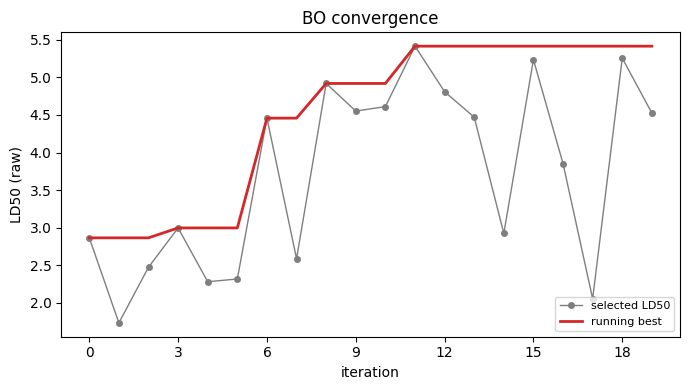

In [4]:
def plot_convergence(trace):
    iters = trace["iteration"].to_numpy()
    ld50 = trace["selected_ld50_raw"].to_numpy()
    running_best = np.maximum.accumulate(ld50)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(iters, ld50, marker="o", ms=4, lw=1.0, color="tab:grey",
            label="selected LD50")
    ax.plot(iters, running_best, lw=2.0, color="tab:red", label="running best")
    ax.set_xlabel("iteration")
    ax.set_ylabel("LD50 (raw)")
    ax.set_title("BO convergence")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    return fig


plot_convergence(data["trace"]);


## 4. Exploration vs exploitation

Each selected point in objective space (mu against sigma), coloured by iteration.
Early picks sit high on sigma (exploration). Later picks drift toward high mu
(exploitation) as the GP sharpens.


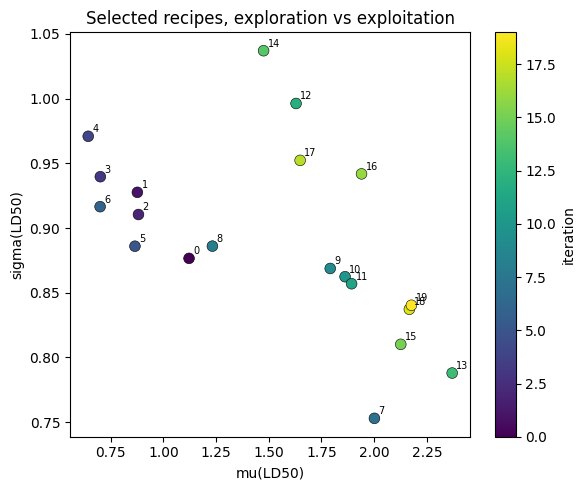

In [5]:
def plot_explore_exploit(selected):
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        selected["mu"], selected["sigma"],
        c=selected["iteration"], cmap="viridis",
        s=60, edgecolors="black", linewidths=0.4,
    )
    for _, row in selected.iterrows():
        ax.annotate(int(row["iteration"]),
                    (row["mu"], row["sigma"]),
                    fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("mu(LD50)")
    ax.set_ylabel("sigma(LD50)")
    ax.set_title("Selected recipes, exploration vs exploitation")
    fig.colorbar(sc, ax=ax, label="iteration")
    fig.tight_layout()
    return fig


plot_explore_exploit(data["selected"]);


## 5. Pareto front evolution

Every iteration's non-dominated front overlaid in objective space, coloured by
iteration. Shows the front advancing toward the utopia corner (top-right).


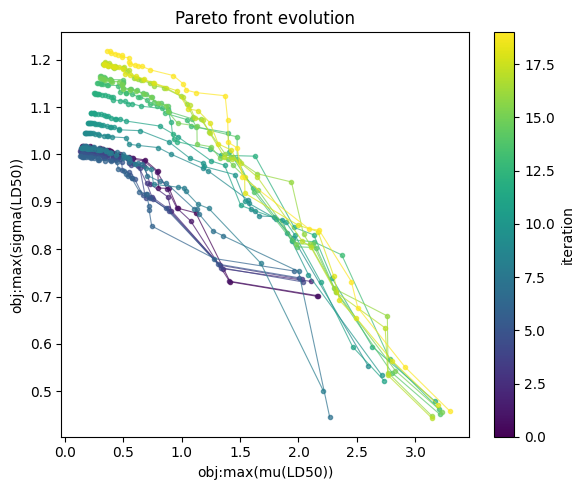

In [6]:
def plot_front_evolution(pareto, mu_col=MU_COL, sigma_col=SIGMA_COL):
    fig, ax = plt.subplots(figsize=(6, 5))
    n = len(pareto)
    cmap = plt.cm.viridis

    for it in sorted(pareto):
        df = pareto[it].sort_values(mu_col)
        color = cmap(it / max(n - 1, 1))
        ax.plot(df[mu_col], df[sigma_col], marker="o", ms=3, lw=0.8,
                color=color, alpha=0.7)

    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=0, vmax=n - 1))
    fig.colorbar(sm, ax=ax, label="iteration")
    ax.set_xlabel(mu_col)
    ax.set_ylabel(sigma_col)
    ax.set_title("Pareto front evolution")
    fig.tight_layout()
    return fig


plot_front_evolution(data["pareto"]);


## 6. Front size per iteration

Number of non-dominated candidates each iteration. A shrinking front as the
observed set grows is normal: fewer unobserved points remain on the frontier.


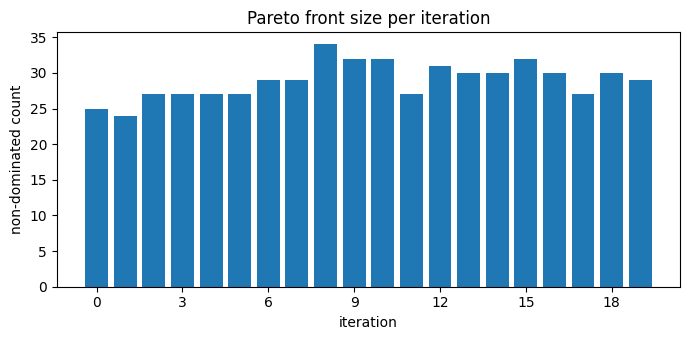

In [7]:
def plot_front_size(trace):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(trace["iteration"], trace["n_non_dominated"], color="tab:blue")
    ax.set_xlabel("iteration")
    ax.set_ylabel("non-dominated count")
    ax.set_title("Pareto front size per iteration")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    fig.tight_layout()
    return fig


plot_front_size(data["trace"]);


## 7. Pool context

Distribution of predicted mu over the full candidate pool at the final
iteration, with the selected molecules marked. Shows where BO picks sit relative
to the whole space.


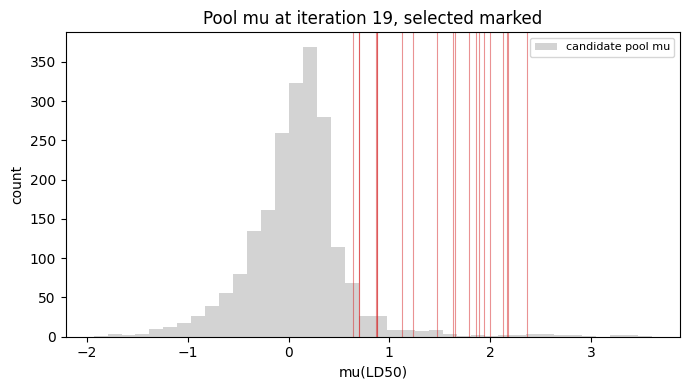

In [8]:
def plot_pool_context(experiments, selected):
    last_it = max(experiments)
    pool_mu = experiments[last_it]["mu"].to_numpy()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(pool_mu, bins=40, color="lightgrey", label="candidate pool mu")
    for mu in selected["mu"]:
        ax.axvline(mu, color="tab:red", lw=0.8, alpha=0.5)
    ax.set_xlabel("mu(LD50)")
    ax.set_ylabel("count")
    ax.set_title(f"Pool mu at iteration {last_it}, selected marked")
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig


plot_pool_context(data["experiments"], data["selected"]);


## 8. Selected molecules

Structures of every selected recipe, labelled with iteration and raw LD50.
Requires RDKit. Skips cleanly if RDKit is not installed.


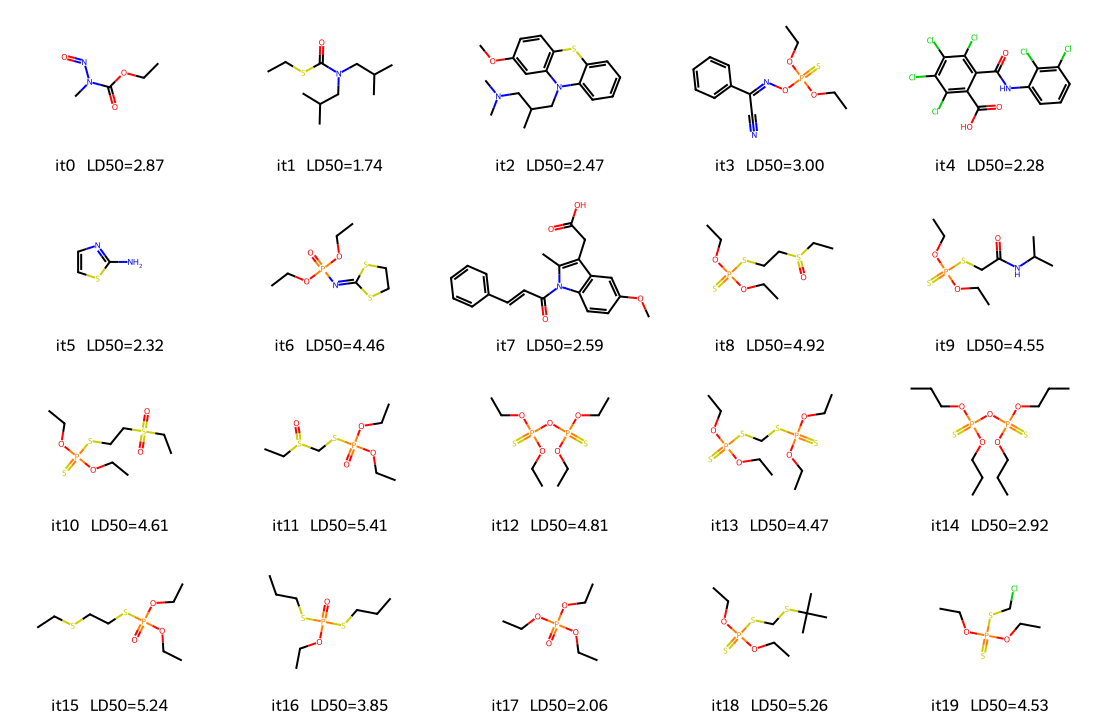

In [9]:
def draw_selected(selected, mols_per_row=5):
    try:
        from rdkit import Chem
        from rdkit.Chem import Draw
    except ImportError:
        print("RDKit not installed, skipping structure grid")
        return None

    mols, legends = [], []
    for _, row in selected.iterrows():
        mol = Chem.MolFromSmiles(str(row["SMILES"]))
        if mol is None:
            continue
        mols.append(mol)
        legends.append(f"it{int(row['iteration'])}  LD50={row['ld50_raw']:.2f}")

    return Draw.MolsToGridImage(
        mols, molsPerRow=mols_per_row, subImgSize=(220, 180), legends=legends
    )


draw_selected(data["selected"])


## 9. Top selected

Selected recipes sorted by raw LD50, the least toxic first. This is the
shortlist to hand back.


In [10]:
top = (
    data["selected"]
    .sort_values("ld50_raw", ascending=False)
    .loc[:, ["iteration", "RecipeID", "SMILES", "ld50_raw", "mu", "sigma", "ucb"]]
    .reset_index(drop=True)
)
top


,iteration,RecipeID,SMILES,ld50_raw,mu,sigma,ucb
0,11,1159,CCOP(=O)(OCC)SCS(=O)CC,5.415,1.892913,0.856962,3.606837
1,18,1154,CCOP(=S)(OCC)SCSC(C)(C)C,5.256,2.166887,0.837248,3.841384
2,15,1000,CCOP(=O)(OCC)SCCSCC,5.236,2.126120,0.810149,3.746418
3,8,1158,CCOP(=S)(OCC)SCCS(=O)CC,4.919,1.232770,0.886007,3.004784
4,12,1166,CCOP(=S)(OCC)OP(=S)(OCC)OCC,4.809,1.629620,0.996229,3.622078
5,10,1069,CCOP(=S)(OCC)SCCS(=O)(=O)CC,4.611,1.862075,0.862390,3.586854
6,9,1065,CCOP(=S)(OCC)SCC(=O)NC(C)C,4.552,1.791695,0.868761,3.529217
7,19,1090,CCOP(=S)(OCC)SCCl,4.525,2.176572,0.840325,3.857222
8,13,1028,CCOP(=S)(OCC)SCSP(=S)(OCC)OCC,4.471,2.370052,0.787957,3.945966
9,6,1691,CCOP(=O)(N=C1SCCS1)OCC,4.458,0.700181,0.916502,2.533186


## Notes for the dashboard

- `get_run` and `load_run` are the whole data layer. Call them once, pass the
  returned dict into any plot function.
- Each `plot_*` returns a Matplotlib figure. For an interactive dashboard, swap
  the bodies for Plotly and keep the same signatures.
- `experiments.csv` does not carry true LD50, only mu, sigma, ucb. To show a
  true-LD50 pool histogram, add `ld50_raw` to the experiments table in
  `run_bo.py`, then this notebook can plot pool truth against selected truth.
